<a href="https://colab.research.google.com/github/ChandrimaGhorai/Bio-AI-projects/blob/main/Clinical_Disease_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Defining the biological markers
column_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigree", "Age", "Outcome"
]

# Loading it into our dataframe (df)
df = pd.read_csv(url, names=column_names)

# View the shape of the data (Rows, Columns)
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 9)


In [11]:
# Count how many rows have a value of 0 in these columns
zero_counts = (df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()
print("Number of impossible 0 values per column:")
print(zero_counts)

Number of impossible 0 values per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [12]:
columns_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_to_fix:
    # Calculate the median of the column, ignoring the 0s
    median_value = df[df[col] != 0][col].median()
    # Replace the 0s with that median
    df[col] = df[col].replace(0, median_value)

print("Data Cleansed! Let's re-verify zeros remaining:")
print((df[columns_to_fix] == 0).sum())

Data Cleansed! Let's re-verify zeros remaining:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


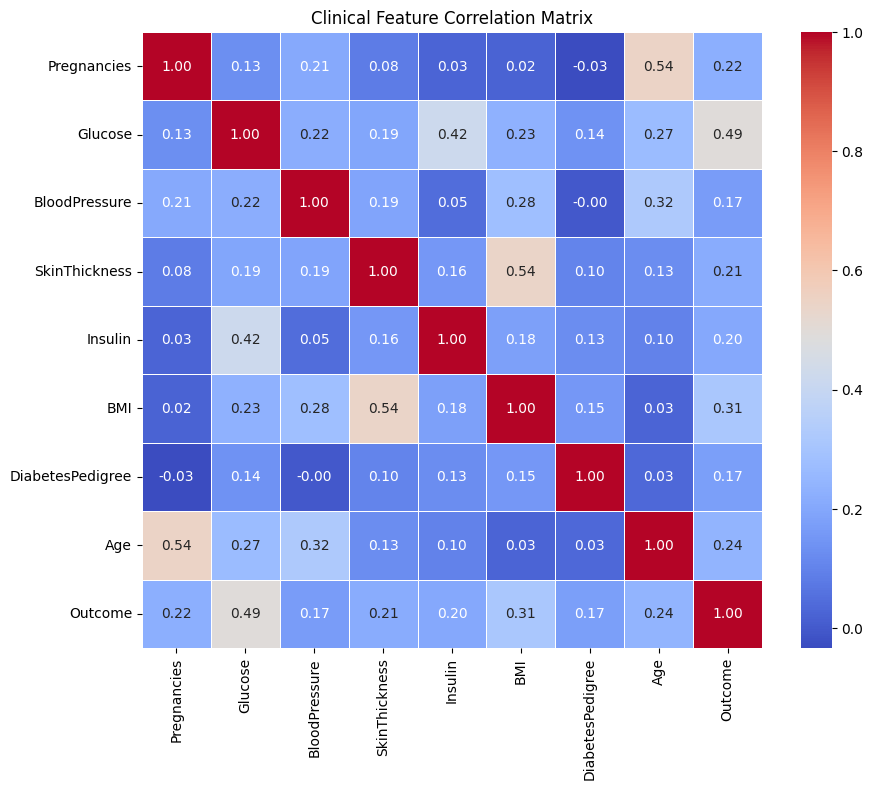

In [13]:
plt.figure(figsize=(10, 8))

# sns.heatmap creates the color-coded grid
# df.corr() calculates the Pearson correlation scores
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Clinical Feature Correlation Matrix")
plt.show()

In [14]:
# Import the splitting tool from Scikit-Learn
from sklearn.model_selection import train_test_split

# 1. Separate our inputs (Biomarkers) from our target output
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 2. Execute the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Splitting Complete!")
print(f"Training shapes - Features: {X_train.shape}, Labels: {y_train.shape}")
print(f"Testing shapes  - Features: {X_test.shape}, Labels: {y_test.shape}")


Data Splitting Complete!
Training shapes - Features: (614, 8), Labels: (614,)
Testing shapes  - Features: (154, 8), Labels: (154,)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
lr_model = LogisticRegression(max_iter=1000)

# Train the model using our training data
lr_model.fit(X_train, y_train)

# Test the model by asking it to predict the test patients
lr_preds = lr_model.predict(X_test)

print("--- LOGISTIC REGRESSION RESULTS ---")
print("Overall Accuracy:", accuracy_score(y_test, lr_preds))

--- LOGISTIC REGRESSION RESULTS ---
Overall Accuracy: 0.7532467532467533


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Test the model
rf_preds = rf_model.predict(X_test)

print("--- RANDOM FOREST RESULTS ---")
print("Overall Accuracy:", accuracy_score(y_test, rf_preds))

--- RANDOM FOREST RESULTS ---
Overall Accuracy: 0.7467532467532467


In [17]:
print("Detailed Clinical Diagnostic Report (Random Forest):")
print(classification_report(y_test, rf_preds))


Detailed Clinical Diagnostic Report (Random Forest):
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [19]:
# Create a function that accepts custom clinical inputs
def predict_new_patient(pregnancies, glucose, bp, skin_thickness, insulin, bmi, pedigree, age):

    # 1. Arrange the inputs exactly into the structure our model expects
    patient_features = [[pregnancies, glucose, bp, skin_thickness, insulin, bmi, pedigree, age]]

    # 2. Use our winning Logistic Regression model to make the prediction
    prediction = lr_model.predict(patient_features)

    # 3. Calculate the exact probability score (confident percentage)
    probability = lr_model.predict_proba(patient_features)[0][1]

    print("=== CLINICAL RISK ASSESSMENT REPORT ===")
    if prediction[0] == 1:
        print(f"⚠️ STATUS: High Risk of Diabetes Detected.")
        print(f"🩺 PROBABILITY SCORE: {probability:.2%}")
    else:
        print(f"✅ STATUS: Low Risk. Patient data appears within normal thresholds.")
        print(f"🩺 PROBABILITY SCORE: {probability:.2%}")
    print("=======================================")

# -------------------------------------------------------------------------
# TEST CASE: Let's run an imaginary patient through your AI!
# Try changing these numbers yourself to see how the model reacts.
# -------------------------------------------------------------------------
predict_new_patient(
    pregnancies=2,
    glucose=150,       # High glucose
    bp=75,
    skin_thickness=25,
    insulin=130,
    bmi=34.2,          # High BMI
    pedigree=0.5,
    age=45             # Older age
)

=== CLINICAL RISK ASSESSMENT REPORT ===
✅ STATUS: Low Risk. Patient data appears within normal thresholds.
🩺 PROBABILITY SCORE: 1.20%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
